## Optimization Fundamentals
**Definition** : Finding the best solution from all feasible solutions given certain constraints and objectives.  

**Components of an Optimization Problem :**
* *Decision variables* : what you can control.  
* *Objective function* : what you want to maximize or minimize.  
* *Contraints* : limitations you must respect.
* *Optimal solution :* the best values for decision variables that optimize the objective while satisfying constraints.


## Combinatorial Optimization Problem
**Combinatorial optimization problems** involve finding the best solution from a finite set of discrete solutions.  
It is also finding the optimum (either maximum or minimum) of an objective function whose domain is discrete.

**Examples of combinatorial optimization problems:**  

* **Traveling Salesman Problem (TSP):** Find the shortest route  visiting all cities exactly once.

* **Graph Coloring:** Assign colors to graph nodes such that no adjacent nodes share the same color, using minimum colors

* **Knapsack Problem:** Select items to maximize value without exceeding weight limit.

* **MaxCut Problem:** Partition graph nodes into two sets to maximize edges between sets.

Many real-world problems in industry, science, and daily life can be formulated as general optimization tasks, which are often too large for exhaustive search. Classical approximation algorithms provide near-optimal solutions within a guaranteed ratio, but their computational complexity remains a major challenge for large-scale instances. In recent years, quantum computing has emerged as a promising alternative, with **variational quantum algorithms** for near-term devices attracting significant attention. Among these, the **Quantum Approximate Optimization Algorithm (QAOA)** has become one of the most studied frameworks, offering a general strategy applicable to a wide class of optimization problems. In this work, we focus on analyzing and improving QAOA’s performance, using the **Max-Cut** problem as a benchmark to evaluate its behavior.

## Variational Method
Method for approximiting ground state $\lvert \psi^*\rangle$ and lowest energy $E_{min}$ of quantum system, and it consists of two steps :  
1. Choose ansatz or trial state paramitrized by $\theta$  
   $$\ket{\psi(\theta)}$$
2. Vary parameters $\theta$ to minimize the energy value
$$E(\theta) = \bra{\psi(\theta)} H \ket{\psi(\theta)}$$

## Variational Quantum Circuit 
A quantum circuit that depends on parameters $\theta_i$  

![](VQC.png)

**VQC** is just a general term for a quantum circuit with parameters optimized classically.  
**QAOA** and **VQE** are instances of **VQCs**.

## Variational Quantum Eigensolvers 
Idea = prepare quantum state with variational quantum circuit $U(\theta)$
$$\ket{\psi(\theta)} = U(\theta)\ket{\psi_0}$$
**VQE** is a general variational algorithm to find the ground state of a Hamiltonian.  
It uses a parametrized quantum circuit and classical optimization.  

![](vqe.png)

## QAOA
QAOA (Quantum Approximate Optimization Algorithm), introduced by Farhi, it is a quantum algorithm that attempts to solve such combinatorial problems.
It is a variational algorithm using a parametrized quantum circuit in which each quantum state represents a possible solution and whose parameters are adjusted to minimize a cost Hamiltonian.  
Before delving deeply into explaining this algorithm and its components, a few things need to be understood first.  
### Adiabatic Theorem(Origin of QAOA)
If a quantum system starts in the ground state of $H_0$ and the Hamiltonian is changed slowly enough, the system remains in the ground state of the evolving Hamiltonian.  
So if we define $$H(t) = (1 - s(t)) H_M + s(t) H_C , t \in [0,1]$$
Where $H_M$ is simple Hamiltonian called by $Mixer Hamiltonian$ whose ground state we know and that is evolved throughout time(slowly transform the Hamiltonian), and $H_C$ is the $Cost Hamiltonian$ that we will end in it and does not commute with $H_M$ and whose ground state we seek which is the final state encodes the optimal solution.  
When considering quantum circuits, it is often convenient to define them by a series of quantum gates. But there are many instances where it is useful to think of a quantum circuit in terms of a Hamiltonian. Indeed, gates are physically implemented by performing time evolution under a carefully engineered Hamiltonian. These transformations are described by the time evolution operator, which is a unitary defined as:
$$U(H, t) = e^{-i H_t/{\hbar}
}$$

The time evolution operator is determined completely in terms of a Hamiltonian $H$ and a scalar $t$ representing time. In fact, any unitary $U$ can be written in the form $e^{i \gamma H}$ where ${\gamma}$ is a scalar and $H$ is a Hermitian operator, interpreted as a Hamiltonian. Thus, time evolution establishes a connection that allows us to describe quantum circuits in terms of Hamiltonians.  
In our case to apply the evolution operator we'll have to construct 
$$U(t) = e^{-i  \int_{0}^{t} H(\tau)d\tau}$$
This is a normal a case of continuous evolution.  
This involves building a quantum circuit that exactly exponentiates a Hamiltonian with many non-commuting terms, which is quite challenging.  
Also in quantum mechanics we often have: $$H = H_C + H_M$$
But the operators do not commute: $$[H_B, H_C] \neq 0$$
Therefore, we cannot simply write $$e^{-i (H_M + H_C)t} = e^{-iH_M t} e^{-iH_C t}$$
Instead we approximate it using Trotter Decomposition:
$$e^{-i (H_M + H_C) t} \approx \left( e^{-i H_M \frac{t}{p}} \, e^{-i H_C \frac{t}{p}} \right)^p $$
This decomposition lets us implement the evolution using separate quantum gates.  
QAOA is basically a digitized approximation of the adiabatic algorithm, so Instead of continuous evolution, QAOA uses layers: 

$$
\ket{\psi(\gamma,\beta)}=\prod_{k=1}^{p} e^{-i \beta_k H_M} \, e^{-i \gamma_k H_C} \, | \psi_0 \rangle
$$
where $p$ is number of QAOA layers and $\gamma_k, \beta_k$ are variational parameters.  
Then the circuit that applies looks like the figure below.
![](qaoa_circuit.png)  
The initial state has to be the ground state of the mixer Hamiltonian to leverage the adiabatic theorem.  
The next step is to optimize the parameters so that the expectation value of the cost Hamiltonian is minimized at the end. This ensures that we are, with high likelihood, generating the correct ground state with our QAOA circuit.  
One intuitive way to understand the QAOA ansatz is to consider $H_C$ as the Hamiltonian representing the problem, whose ground state encodes the solution we aim to find, while $H_M$ serves as the driver Hamiltonian that steers the system through the search space toward that solution.  
So the global idea is to start from the known ground state of $H_M$ and gradually evolve the circuit parameters, updating the cost function so that it approaches $H_C$. According to the adiabatic theorem, the system remains in the ground state throughout this evolution, ensuring that the final measured quantum state corresponds to the ground state of $H_C$.

## QAOA - Steps 
1. Represent your combinatorial optimization problem as a cost Hamiltonian  $H_C$, whose ground state corresponds to the optimal solution.
2. Define a mixer Hamiltonian $H_M$
3. Construct the circuits $e^{-i\beta H_M}$ and $e^{-i\gamma H_C }$, the mixer and cost layers, respectively.
4. Choose a parameters and build the circuit$$
U(\gamma, \beta)
=
\underbrace{
e^{-i \beta_n H_M} e^{-i \gamma_n H_C} \cdots
\underbrace{e^{-i \beta_1 H_M} e^{-i \gamma_1 H_C}}_{\text{one layer}}
}_{\text{$p$ layers}}
$$ consisting of repeated application of the cost and mixer layers.
5. Prepare an initial state $U(\gamma, \beta)$, apply and use classical techniques to optimize the parameters.
6. After the circuit has been optimized, measurements of the output state reveal approximate solutions to the optimization problem.
   
I will demonstrate these steps using the Max-Cut problem discussed below. For that, I would first define the underlying graph of the problem as shown below.

## Max-Cut problem 
**Graph** is set of verices or nodes V connected by edges E.  
1. **Max-Cut (Unweighted)**  
Given an undirected graph $G = (V, E)$ with **vertices** $V$ and **edges** $E$, the **Max-Cut** problem asks you to partition the set of vertices $V$ into two disjoint subsets $S$ and $V/S$ such that the number of edges between the two subsets is maximized.
* Each edge counts as 1 if it connects a vertex in $S$ to a vertex in $S/V$.
* **Goal**: Maximize the total number of “cut edges.”
Example:
Graph with vertices $V = \{0,1,2,3\}$ and edges $E = \{(0, 1),(1, 2),(2, 3),(3, 0)\}$  
Partition $S = \{0,2\}, V/S = \{1,3\}$  
Cut edges: $(0, 1),(1, 2),(2, 3),(3, 0) \rightarrow$ 4 edges cut $\rightarrow$ maximal cut

2. **Max-Cut (Weighted)**
Given an undirected graph $G = (V, E)$ with weights $w_{ij} \ge 0$ on each edge $(i,j)$ the Weighted **Max-Cut** problem asks you to partition the vertices into two subsets $S$ and $V/S$ such that the sum of the weights of edges crossing the partition is maximized.
* Each edge contributes its weight $w_{ij}$ to the cut if its endpoints are in different subsets.
* Goal:  $$\text{maximize} \quad \sum_{(i,j) \in E, i \in S, j \in V \setminus S} w_{ij}$$
Example:
Same graph as before, but edge weights: $w_{0,1} = 3, w_{1,2} = 2, w_{2,3} = 5, w_{3,0} = 1 $
Partition $S = \{0,2\}, V/S = \{1,3\}$  
Cut edges: $(0, 1)=3, (1, 2)=2, (2, 3)=5, (3, 0)=1 \rightarrow$ Total weight $=11 \rightarrow$ maximal cut.

---

Let's consider a graph with $m$ edges and $n$ vertices. We seek the partition $z$ of the vertices into two sets $A$ and $B$ which maximize
$$C(z) =\sum_{\alpha = 1}^{m} C_{\alpha}(z) $$
where $C$ counts the number of edges cut. $C_{\alpha}(z) = 1$ if $z$ places one vertex from the $\alpha^{th}$ edge in set $A$ and the other in set $B$, and $C_{\alpha}(z) = 0$ otherwise. Finding a cut which yields the maximum possible value of $C$ is an NP-complete problem, so our best hope for a polynomial-time algorithm lies in an approximate optimization. In the case of MaxCut, this means finding a partition $z$ which yields a value for $C(z)$ that is close to the maximum possible value.  
We can represent the assignment of vertices to set $A$ or $B$ using a bitstring, $z=z_1...z_n$ where $z_i = 0$ if the $i^{th}$ vertex is in $A$ and $z_i=1$ if it is in $B$. For instance, in the situation depicted in the figure above the bitstring representation is $z=0101$ indicating that the $0^{th}$ and $2^{nd}$ vertices are in $A$ while the $1^{st}$ and $3^{rd}$ are in $B$. This assignment yields a value for the objective function $C=4$, which turns out to be the maximum cut.  
In the graph above, $z=1010$ could equally well serve as the maximum cut.

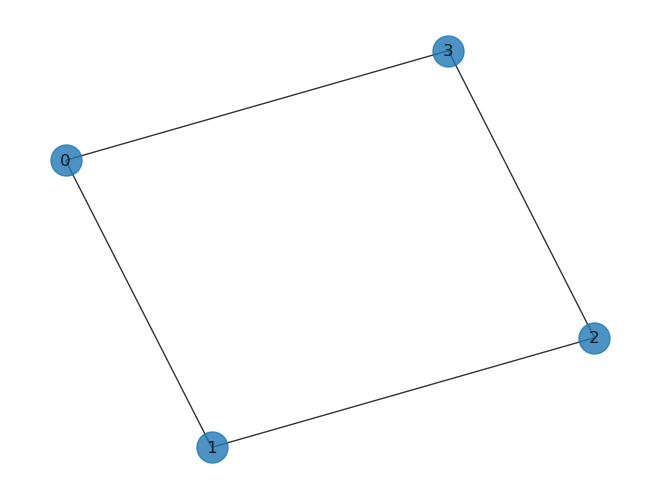

In [1]:
import networkx as nx
graph = nx.Graph()
graph.add_nodes_from([0, 1, 2, 3])
graph.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 0)])
nx.draw(graph, with_labels=True, alpha=0.8, node_size=500)

Let's break down the problem  
We need a quantum cost Hamiltonian $H_C$ to encode the Max-Cut objective:  
1. Assign binary variables $x_i \in \{0,1\}$ to each vertex:  
   $x_i = 0$ vertex in $Set A$  
   $x_i = 1$ vertex in $Set B$
2. Edge contribution:
   $C_{ij}= 1$ vertices $i$ and $j$ in different sets  
   $C_{ij}= 0$ vertices $i$ and $j$ in same set
3. Total cost (number of cut edges):
   $$C(x) =\sum_{ij \in E} C_{ij} $$

As we know quantum operators work with Pauli matrices, which take eigenvalues ±1, so we need to change our binary variables into spin variables $\{0,1\}$ to $\{1,-1\}$ 
$$z_i = 1-2x_i \in \{+1,-1\}$$
That allows direct use of Pauli-Z operators in the Hamiltonian.
Next we will express the Hamiltonian using Pauli-Z operators  
Edge contribution in spin form: $$C_{ij} = \frac{1}{2}(1-z_iz_j)$$
if vertices are in same set : $z_iz_j = 1 \rightarrow C_{ij} = 0$  
If vertices are in different sets: $z_iz_j = -1 \rightarrow C_{ij} = 1$  
Cost Hamiltonian  $$H_C =\sum_{ij \in E} \frac{1}{2}(1-Z_iZ_j) $$
where $Z_i = $ Pauli-Z operator acting on qubit

## Implementation
The problem Hamiltonian specific to our Max-Cut problem is:
$$
H_C = \frac{1}{2}\big(I_0 \otimes I_1 \otimes I_2 \otimes I_3 - Z_0 \otimes Z_1 \otimes I_2 \otimes I_3\big) + 
      \frac{1}{2}\big(I_0 \otimes I_1 \otimes I_2 \otimes I_3 - I_0 \otimes Z_1 \otimes Z_2 \otimes I_3\big) +
      \frac{1}{2}\big(I_0 \otimes I_1 \otimes I_2 \otimes I_3 - I_0 \otimes I_1 \otimes Z_2 \otimes Z_3\big) +
      \frac{1}{2}\big(I_0 \otimes I_1 \otimes I_2 \otimes I_3 - Z_0 \otimes I_1 \otimes I_2 \otimes Z_3\big)
$$
The mixer Hamiltonian $H_M$ is usually of the form:

$$
H_M = \big(X_0 \otimes I_1 \otimes I_2 \otimes I_3 \big) + 
      \big(I_0 \otimes X_1 \otimes I_2 \otimes I_3 \big) +
      \big(I_0 \otimes I_1 \otimes X_2 \otimes I_3 \big) +
      \big(I_0 \otimes I_1 \otimes I_2 \otimes X_3 \big)
$$

### Mixer Unitary

The mixer Hamiltonian is:

$$
H_M = X_0 + X_1 + X_2 + X_3
$$

Since the terms commute, the unitary can be factorized as:

$$
U(H_M) = e^{-i \beta H_B} = e^{-i \beta X_0} \, e^{-i \beta X_1} \, e^{-i \beta X_2} \, e^{-i \beta X_3}
$$

Each term corresponds to a single-qubit **RX rotation**.

---

### Cost Unitary

The cost Hamiltonian for a 4-qubit square graph with edges \((0,1),(1,2),(2,3),(3,0)\) is:

$$
H_C = \frac{1}{2}\big(I - Z_0 Z_1\big) + \frac{1}{2}\big(I - Z_1 Z_2\big) + \frac{1}{2}\big(I - Z_2 Z_3\big) + \frac{1}{2}\big(I - Z_0 Z_3\big)
$$

The cost unitary is:

$$
\begin{aligned}
U(H_C) &= e^{-i \gamma H_C} \\
&= e^{-i \frac{\gamma}{2}(I - Z_0 Z_1)} \, 
   e^{-i \frac{\gamma}{2}(I - Z_1 Z_2)} \, 
   e^{-i \frac{\gamma}{2}(I - Z_2 Z_3)} \, 
   e^{-i \frac{\gamma}{2}(I - Z_0 Z_3)}
\end{aligned}
$$


### Mixer Unitary

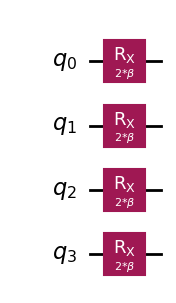

In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.circuit import Parameter

adjacency = nx.adjacency_matrix(graph).todense()  # just stores adjacency (not used in mixer)
N_QUBITS = 4  #because we have 4 verices 

beta = Parameter("$\\beta$")
qc_mix = QuantumCircuit(N_QUBITS)

for i in range(N_QUBITS):
    qc_mix.rx(2 * beta, i)  # Apply RX rotation to each qubit

qc_mix.draw('mpl')

### Cost Unitary

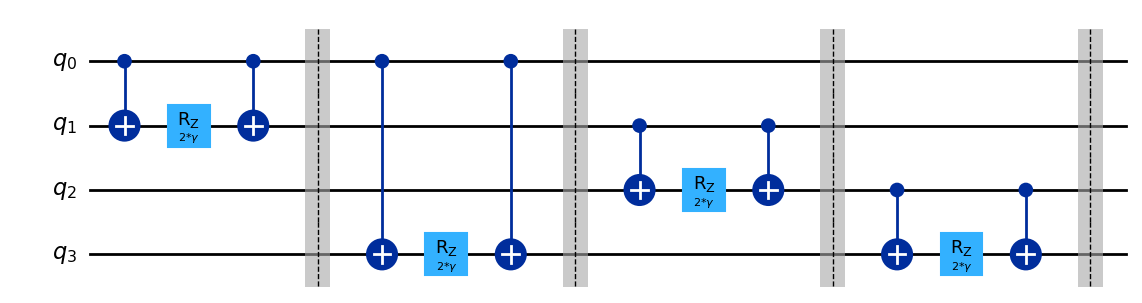

In [9]:
gamma = Parameter("$\\gamma$")
qc_cost = QuantumCircuit(N_QUBITS)
for pair in list(graph.edges()):  # pairs of nodes
    qc_cost.rzz(2 * gamma, pair[0], pair[1])
    qc_cost.barrier()

qc_cost.decompose().draw('mpl')

### The Initial State
The initial state used during QAOA is usually an equal superposition of all the basis states  
$$\lvert \psi_0 \rangle = \bigg(\frac{1}{\sqrt{2}}\big(\lvert 0 \rangle + \lvert 1 \rangle\big)\bigg)^{\otimes n}$$
In our exapmle when the number of qubits is 4 ($n=4$), can be prepared by applying Hadamard gates starting from an all-zero state as shown in 
the circuit below. 

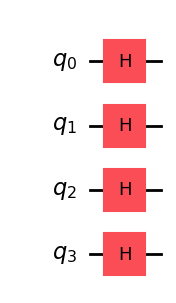

In [11]:
qc_0 = QuantumCircuit(N_QUBITS)
for i in range(N_QUBITS):
    qc_0.h(i)

qc_0.draw('mpl')

### The QAOA circuit

We have seen that the preparation of a quantum state during QAOA is composed of three elements:
1. Preparing an initial state
2. Applying the unitary $ U(H_C) = e^{-i \gamma H_C}$ corresponding to the problem Hamiltonian
3. Then, applying the mixing unitary $ U(H_M) = e^{-i \beta H_M}$

Let's see what it looks like for our example problem:

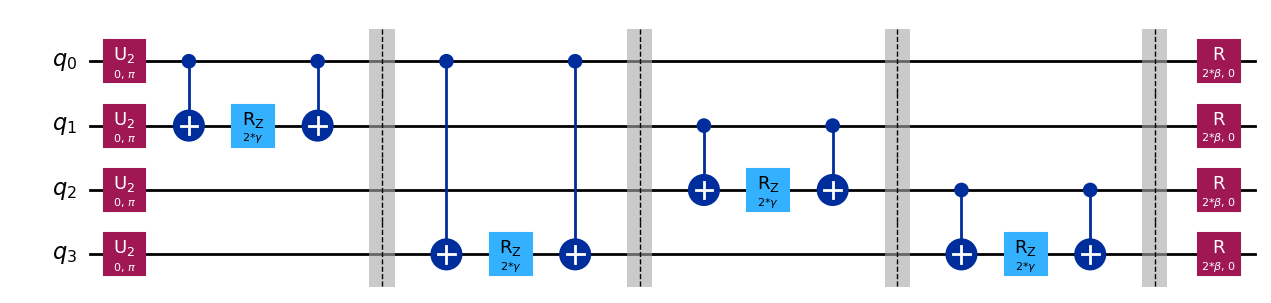

In [13]:
qc_qaoa = QuantumCircuit(N_QUBITS)
qc_qaoa.append(qc_0, range(N_QUBITS))
qc_qaoa.append(qc_cost, range(N_QUBITS))
qc_qaoa.append(qc_mix, range(N_QUBITS))

qc_qaoa.decompose().decompose().draw('mpl')

### Optimization part 
The next step is to find the optimal parameters $ (\boldsymbol{\beta_{\text{opt}}}, \boldsymbol{\gamma_{\text{opt}}})`$ such that the expectation value

$$ \langle \psi(\boldsymbol{\beta}_{\text{opt}}, \boldsymbol{\gamma}_{\text{opt}}) \rvert H_C \lvert 
\psi(\boldsymbol{\beta}_{\text{opt}}, \boldsymbol{\gamma}_{\text{opt}}) \rangle $$

is minimized. Such an expectation can be obtained by doing measurement in the Z-basis. We use a classical optimization algorithm to find the optimal parameters. Follow the next steps :  
1. Initialize $\boldsymbol{\beta}$ and $\boldsymbol{\gamma}$ to suitable real values.
2. Repeat until some suitable convergence criteria is met:
    1. Prepare the state $\lvert \psi(\boldsymbol{\beta}, \boldsymbol{\gamma}) \rangle$ using the QAOA circuit
    2. Measure the state in standard basis
    3. Compute $ \langle \psi(\boldsymbol{\beta}, \boldsymbol{\gamma}) \rvert H_P \lvert \psi(\boldsymbol{\beta}, \boldsymbol{\gamma}) \rangle $ 
    4. Find new set of parameters $ (\boldsymbol{\beta}_{new}, \boldsymbol{\gamma}_{new})$ using a classical optimizer
    5. Set current parameters $(\boldsymbol{\beta}, \boldsymbol{\gamma})$ equal to the new parameters 
      $ (\boldsymbol{\beta}_{new}, \boldsymbol{\gamma}_{new})$

## Full implementation 
[Pennylane](https://github.com/ishakt9h/QAOA/blob/main/QAOA/QAOA_MaxCut_pennylane.ipynb)  
[QisKit](https://github.com/ishakt9h/QAOA/blob/main/QAOA/QAOA_QisKit.ipynb)

## Resources
1. Farhi, Edward, Jeffrey Goldstone, and Sam Gutmann. "A quantum approximate optimization algorithm." arXiv preprint [arXiv:1411.4028 (2014)](https://arxiv.org/abs/1411.4028).
2. [IBM Documentation](https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm)
3. [Intro to QAOA by Pennulane](https://pennylane.ai/qml/demos/tutorial_qaoa_intro)